In [1]:
import yfinance as yf

In [2]:
btc = yf.download('BTC-USD', period='10y', interval='1d', auto_adjust=False, progress=False)


In [21]:
if type(btc.columns).__name__ == 'MultiIndex':
    btc.columns = btc.columns.get_level_values(0)

if btc.empty:
    raise ValueError('No data downloaded for BTC-USD. ')

btc.to_csv('btc.csv')


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [5]:
btc.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-03-06,407.707001,407.707001,411.907013,395.778015,400.524994,91212496
2016-03-07,414.321014,414.321014,415.916992,406.308990,407.756989,85762400
2016-03-08,413.971985,413.971985,416.243011,411.093994,414.464996,70311696
2016-03-09,414.859985,414.859985,416.032013,411.605988,413.894012,70012304
2016-03-10,417.131012,417.131012,417.511993,413.251007,414.743988,81022896


In [6]:
btc.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-03-02,68775.851562,68775.851562,70044.000000,65303.136719,65734.078125,56698092052
2026-03-03,68293.648438,68293.648438,69232.890625,66237.617188,68785.078125,47947999049
2026-03-04,72710.578125,72710.578125,74051.804688,67437.406250,68290.562500,75073101274
2026-03-05,70841.125000,70841.125000,73555.789062,70654.882812,72712.656250,51172841727
2026-03-06,70014.062500,70014.062500,71336.351562,69755.875000,70878.656250,44336181248


In [7]:
btc.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3653 entries, 2016-03-06 to 2026-03-06
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  3653 non-null   float64
 1   Close      3653 non-null   float64
 2   High       3653 non-null   float64
 3   Low        3653 non-null   float64
 4   Open       3653 non-null   float64
 5   Volume     3653 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 199.8 KB


In [8]:
btc.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03
mean,31674.180414,31674.180414,32289.091571,30979.439670,31656.281967,2.522774e+10
std,32485.758188,32485.758188,33023.506335,31896.842567,32484.309437,2.296318e+10
min,407.707001,407.707001,410.984009,395.778015,400.524994,2.851400e+07
25%,6644.129883,6644.129883,6789.022949,6540.049316,6643.100098,6.120120e+09
50%,19268.093750,19268.093750,19542.539062,18925.603516,19246.919922,2.129438e+10
75%,49058.667969,49058.667969,50341.101562,47414.210938,49072.585938,3.659944e+10
max,124752.531250,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [9]:
btc.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [10]:
btc.isna().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [11]:
btc.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [12]:
btc = btc[['Open','High','Low','Close','Volume']]

In [13]:
#Feature Engineering
btc['Log_Return'] = np.log(btc['Close'] / btc['Close'].shift(1))
btc.dropna(inplace=True)

In [14]:
btc = btc[['Open','High','Low','Close','Volume','Log_Return']]

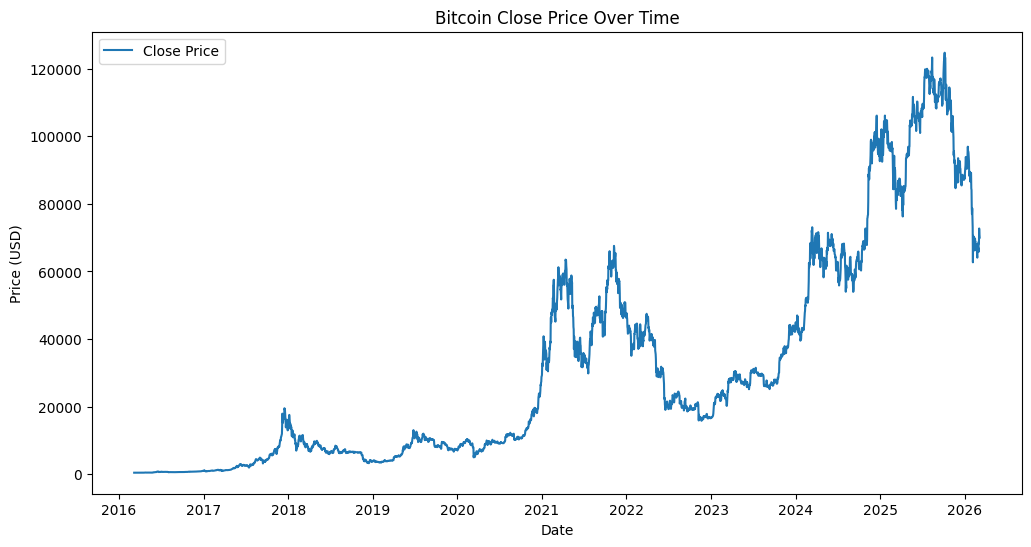

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(btc['Close'], label='Close Price')
plt.title('Bitcoin Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [16]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(btc[['Close']])

In [17]:
X, y = [], []
for i in range(60, len(data_scaled)):
    X.append(data_scaled[i - 60:i, 0])
    y.append(data_scaled[i, 0])

X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

model_lstm = Sequential([
    Input(shape=(X.shape[1], 1)),
    LSTM(units=50, return_sequences=True),
    LSTM(units=50),
    Dense(1)
])

model_lstm.compile(loss='mean_squared_error', optimizer='adam')
model_lstm.fit(X, y, epochs=10, batch_size=32, verbose=0)


In [18]:
train_predictions_scaled = model_lstm.predict(X, verbose=0)
train_predictions = scaler.inverse_transform(train_predictions_scaled)
y_actual = scaler.inverse_transform(y.reshape(-1, 1))

lstm_rmse = float(np.sqrt(mean_squared_error(y_actual, train_predictions)))
print(f'LSTM RMSE: {lstm_rmse:.4f}')

pred_input = data_scaled[-60:]
pred_input = pred_input.reshape(1, 60, 1)

lstm_predictions = []

for _ in range(30):
    next_pred = model_lstm.predict(pred_input, verbose=0)[0][0]
    lstm_predictions.append(next_pred)
    pred_input = np.append(pred_input[:, 1:, :], [[[next_pred]]], axis=1)

lstm_predictions_actual = scaler.inverse_transform(np.array(lstm_predictions).reshape(-1, 1))


LSTM RMSE: 2012.4053


In [19]:
last_date = btc.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
lstm_forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Close_Price': lstm_predictions_actual.flatten()
})
lstm_forecast = lstm_forecast_df.set_index('Date')
lstm_forecast


,Predicted_Close_Price
Date,
2026-03-07,69376.257812
2026-03-08,69778.562500
2026-03-09,70038.398438
2026-03-10,70209.898438
2026-03-11,70325.718750
2026-03-12,70405.851562
2026-03-13,70462.414062
2026-03-14,70502.960938
2026-03-15,70532.179688
